# **Laboratorio 1.4, Física computacional 1**

Juan Esteban Garces Duran

C.C 1077225154

En este trabajo se aborda la solución del problema electrostático correspondiente a un capacitor de placas paralelas mediante la resolución numérica de la ecuación de Laplace.

Dado que en la región entre las placas no hay presencia de carga libre, el potencial eléctrico satisface la ecuación:

$$
\nabla^2 \phi = 0
$$

Debido a la geometría del sistema y a la dificultad de obtener una solución analítica exacta en un dominio finito, se recurre a un método numérico basado en diferencias finitas.

Para ello, el espacio se discretiza en una malla bidimensional uniforme, en la cual el potencial eléctrico se define en cada punto de la red. La ecuación de Laplace se aproxima mediante una relación algebraica que establece que el potencial en cada punto es igual al promedio de sus vecinos más cercanos.

A partir de esta discretización, se implementa un método iterativo de relajación que permite obtener progresivamente una solución estable.

Las condiciones de frontera se imponen fijando el potencial en las placas del capacitor, asignando valores constantes y opuestos, mientras que en los bordes del dominio se consideran condiciones que aproximan el comportamiento en el infinito. Durante el proceso iterativo, estos valores se mantienen constantes, garantizando que la solución final sea consistente con las condiciones físicas del problema.

De esta manera, tras un número suficiente de iteraciones, se obtiene una aproximación del potencial eléctrico en toda la región, a partir de la cual es posible calcular el campo eléctrico y analizar su comportamiento dentro del sistema.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
#Parametros iniciales, tamaño n de la malla y voltaje de cada placa del capacitor.
n=200              #Malla de 200 unidades
v0=50              #Voltaje inicial de 50 voltios por placa.

#Usamos la división entera para mantener la discretización.
#Tamaño de las placas y separación.
l=n//5              #Longitud de la quinta parte de la malla.
d=n//10             #Distancia entre placas de la decima parte de la malla.


#Posición de las placas. Placa positiva a la izquierda, negativa a la derecha.
col_pos=n//2-d//2            #Columna positiva a d/2 unidades a la izquierda del centro.
col_neg=n//2+d//2           #Columna negativa a d/2 unidades a la derecha del centro.

fila_inicio=n//2-l//2        #Fila a l/2 unidades abajo del centro.
fila_fin=n//2+l//2           #Fila a l/2 unidades arriba del centro.


#Potencial inicial.
u=np.zeros((n,n))

#Placa positiva:
u[fila_inicio:fila_fin,col_pos]=v0

#Placa negativa:
u[fila_inicio:fila_fin,col_neg]=-v0


#Creamos una mascara que fije el valor del potencial en las placas. Esto hara que no tengamos problemas al calcular.
mask = np.zeros_like(u, dtype=bool)
mask[fila_inicio:fila_fin, col_pos] = True
mask[fila_inicio:fila_fin, col_neg] = True

#Solucionamos Laplace mediante diferencias finitas, solucionando para 300 iteraciones.
iteraciones=300
for k in range(iteraciones):
  u_old=u.copy()
  for i in range(1,n-1):
    for j in range(1,n-1):
      if not mask[i,j]:      #No actualizar los valores del potencial en las placas.
        u[i,j]=0.25*(u_old[i+1,j]+u_old[i-1,j]+u_old[i,j+1]+u_old[i,j-1])


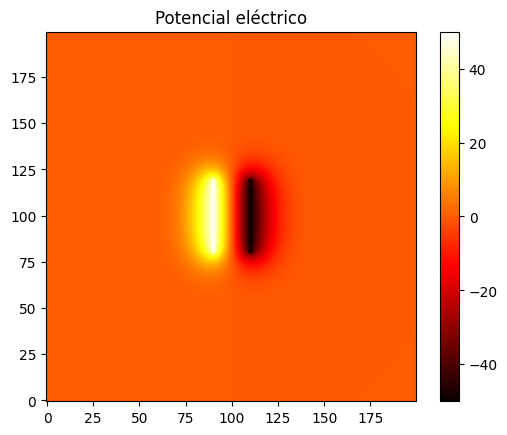

In [13]:
#Graficamos.
plt.imshow(u, cmap="hot", origin='lower')
plt.title('Potencial eléctrico')
plt.colorbar()
plt.show()

# Cálculo del campo eléctrico

## Punto de partida

El campo eléctrico se obtiene a partir del gradiente del potencial eléctrico:

$$
\vec{E} = -\nabla \phi
$$

En dos dimensiones, esto se expresa como:

$$
E_x = -\frac{\partial \phi}{\partial x}, \quad
E_y = -\frac{\partial \phi}{\partial y}
$$

## Aproximación mediante diferencias finitas

Para calcular numéricamente estas derivadas, se emplea el método de diferencias finitas centrales. Para cada punto de la malla, las derivadas se aproximan como:

$$
E_x(i,j) = -\frac{\phi_{i,j+1} - \phi_{i,j-1}}{2}
$$

$$
E_y(i,j) = -\frac{\phi_{i+1,j} - \phi_{i-1,j}}{2}
$$

En este caso, se asume que los pasos espaciales son iguales en ambas direcciones, es decir:

$$
\Delta x = \Delta y = 1
$$

lo cual simplifica las expresiones anteriores.

Estas aproximaciones corresponden a un esquema de diferencias finitas centrales de segundo orden, el cual proporciona una buena precisión para el cálculo del campo eléctrico a partir del potencial obtenido numéricamente.

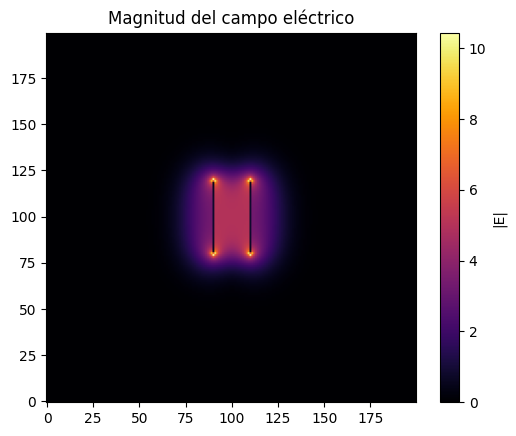

In [14]:
Ex=np.zeros_like(u)
Ey=np.zeros_like(u)

for i in range(1,n-1):
  for j in range(1,n-1):
    Ex[i,j]=-(u[i,j+1]-u[i,j-1])/2
    Ey[i,j]=-(u[i+1,j]-u[i-1,j])/2

#Tenemos ahora las componentes Ex y Ey del campo electrico. Para graficar usando imshow, usare el modulo del vector.
E=np.sqrt(Ex**2+Ey**2)
plt.imshow(E,cmap='inferno',origin='lower')
plt.colorbar(label='|E|')
plt.title('Magnitud del campo eléctrico')
plt.show()